# Notebook 01 — Data Collection
## Semantic Book Recommender | IT4142

**Mục tiêu notebook này:**
- Tải dataset từ Kaggle
- Kiểm tra cấu trúc thô ban đầu (shape, dtypes, missing values)
- Lưu vào `data/raw/books.csv`

> Notebook này **không** thực hiện cleaning hay EDA — đó là việc của notebook 02 và 03.

---

## 1. Thiết lập thư mục dự án

In [153]:
import os
import pandas as pd
import shutil
import warnings
warnings.filterwarnings('ignore')

# Tạo cấu trúc thư mục chuẩn cho folder AI
DIRS = [
    'data/raw',
    'data/processed',
    'data/eval',
    'data/chroma_db',
    'models',
    'reports/figures',
]

for d in DIRS:
    os.makedirs(d, exist_ok=True)

print('Project directory structure created:')
for d in DIRS:
    print(f'  {d}/')

Project directory structure created:
  data/raw/
  data/processed/
  data/eval/
  data/chroma_db/
  models/
  reports/figures/


In [154]:
SOURCE_PATH = '/Users/taduylam/Workspace/IT4930/data_collection/books.csv'
RAW_PATH = 'data/raw/books.csv'

if os.path.exists(RAW_PATH):
    print(f'Dataset already exists at {RAW_PATH} — skip copy.')
else:
    print(f'Copying dataset from {SOURCE_PATH} to {RAW_PATH}...')
    shutil.copy(SOURCE_PATH, RAW_PATH)
    print('Copy complete.')

Dataset already exists at data/raw/books.csv — skip copy.


## 3. Load và kiểm tra sơ bộ

In [155]:
df = pd.read_csv(RAW_PATH)

print('=== DATASET OVERVIEW ===')
print(f'Shape      : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory     : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print()
df.head(3)

=== DATASET OVERVIEW ===
Shape      : 12,688 rows × 12 columns
Memory     : 13.64 MB



,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002188319,0002188317,The Complete Book of the World Cup,"All the Facts, Figures and Match Reports from ...",Cris Freddi,Soccer,https://books.google.com/books/content?id=HGbQ...,This is the ultimate reference book on the Wor...,1998.0,NaN,352.0,NaN
1,9780002240802,0002240807,The Last Thing He Wanted,NaN,Joan Didion,Adventure stories,NaN,"Journalist Elena McMahon watches her evasive, ...",1997.0,NaN,227.0,NaN
2,9780002246484,0002246481,Royal Assassin,NaN,Robin Hobb,Assassins,https://books.google.com/books/content?id=B_Dt...,Barely escaping with his life after his first ...,1996.0,NaN,579.0,NaN


## 4. Kiểm tra kiểu dữ liệu các cột

In [156]:
print('=== COLUMN TYPES ===')
type_info = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Non-null count': df.count().values,
    'Null count': df.isnull().sum().values,
    'Null %': (df.isnull().sum().values / len(df) * 100).round(2),
    'Sample value': [str(df[col].dropna().iloc[0])[:60] if df[col].notna().any() else 'ALL NULL'
                     for col in df.columns]
})
print(type_info.to_string(index=False))

=== COLUMN TYPES ===
        Column   Dtype  Non-null count  Null count  Null %                                                 Sample value
        isbn13   int64           12688           0    0.00                                                9780002188319
        isbn10     str           12113         575    4.53                                                   0002188317
         title     str           12688           0    0.00                           The Complete Book of the World Cup
      subtitle     str            5542        7146   56.32 All the Facts, Figures and Match Reports from Every Tourname
       authors     str           12620          68    0.54                                                  Cris Freddi
    categories     str           11368        1320   10.40                                                       Soccer
     thumbnail     str           11850         838    6.60 https://books.google.com/books/content?id=HGbQOQAACAAJ&print
   description     

## 5. Kiểm tra missing values theo cột

=== MISSING VALUES ===
  published_year          26 rows  (  0.20%)  
  authors                 68 rows  (  0.54%)  
  num_pages              151 rows  (  1.19%)  
  isbn10                 575 rows  (  4.53%)  ██
  thumbnail              838 rows  (  6.60%)  ███
  categories            1320 rows  ( 10.40%)  █████
  subtitle              7146 rows  ( 56.32%)  ████████████████████████████
  average_rating       10944 rows  ( 86.25%)  ███████████████████████████████████████████
  ratings_count        10944 rows  ( 86.25%)  ███████████████████████████████████████████


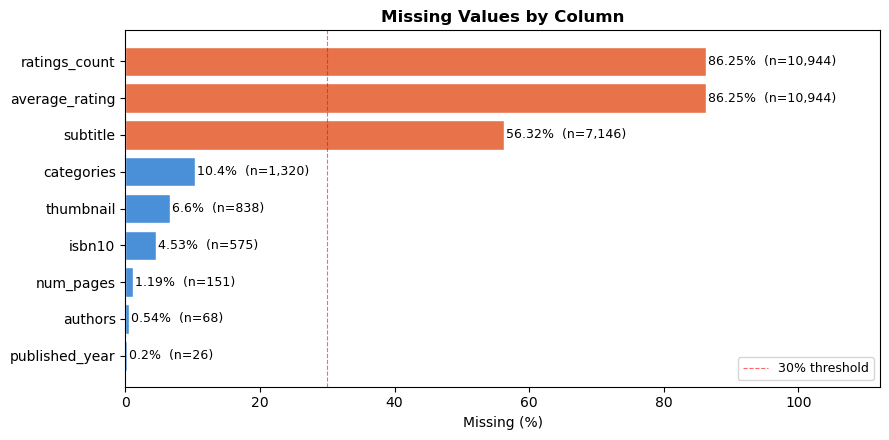

Saved → reports/figures/missing_values.png


In [157]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=True)
missing_pct = (missing / len(df) * 100).round(2)

print('=== MISSING VALUES ===')
for col in missing.index:
    bar = '█' * int(missing_pct[col] / 2)
    print(f'  {col:<20} {missing[col]:>5} rows  ({missing_pct[col]:>6.2f}%)  {bar}')

if len(missing) == 0:
    print('  No missing values found.')

# Plot
if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(9, max(3, len(missing) * 0.5)))
    colors = ['#E8734A' if p > 30 else '#4A90D9' for p in missing_pct]
    bars = ax.barh(missing.index, missing_pct, color=colors, edgecolor='white')
    for bar, pct, cnt in zip(bars, missing_pct, missing):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{pct}%  (n={cnt:,})', va='center', fontsize=9)
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Values by Column', fontweight='bold', fontsize=12)
    ax.set_xlim(0, missing_pct.max() * 1.3)
    ax.axvline(x=30, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='30% threshold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('reports/figures/missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/figures/missing_values.png')

## 6. Kiểm tra duplicate

In [158]:
dup_all   = df.duplicated().sum()
dup_isbn  = df.duplicated(subset='isbn13').sum() if 'isbn13' in df.columns else 'N/A'
dup_title = df.duplicated(subset='title').sum()  if 'title'  in df.columns else 'N/A'

print('=== DUPLICATE CHECK ===')
print(f'  Full-row duplicates    : {dup_all}')
print(f'  Duplicate isbn13       : {dup_isbn}')
print(f'  Duplicate title        : {dup_title}')

if dup_isbn and dup_isbn > 0:
    print()
    print('Sample duplicate isbn13 entries:')
    dup_mask = df.duplicated(subset='isbn13', keep=False)
    print(df[dup_mask][['isbn13', 'title', 'authors']].head(6).to_string(index=False))

=== DUPLICATE CHECK ===
  Full-row duplicates    : 0
  Duplicate isbn13       : 0
  Duplicate title        : 1066


## 7. Kiểm tra nhanh cột `description` — cột quan trọng nhất

=== DESCRIPTION COLUMN STATS ===
  Non-null count     : 12,688 / 12,688
  Empty string count : 0
  Word count — min   : 20
  Word count — max   : 1048
  Word count — mean  : 136.5
  Word count — median: 118.0



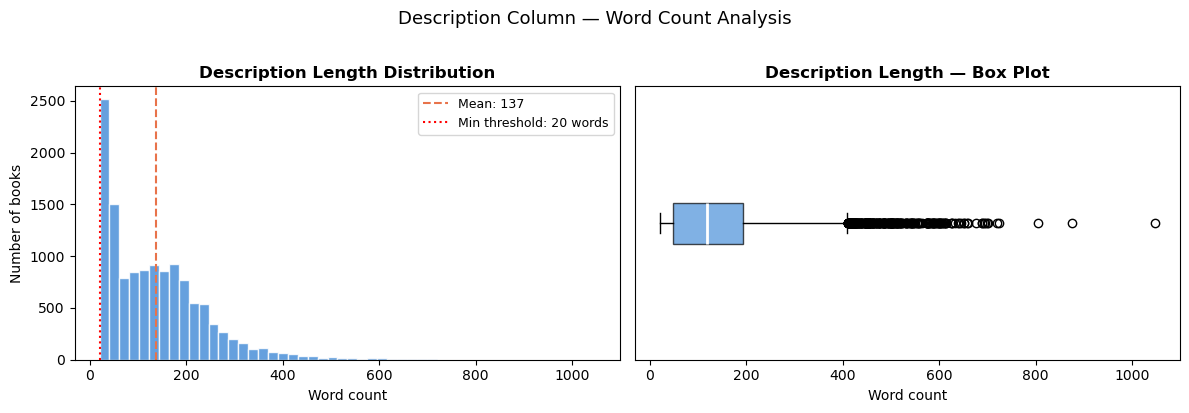

Saved → reports/figures/description_length_raw.png

  Descriptions with < 20 words: 0 (will be filtered in preprocessing)


In [159]:
desc = df['description'].dropna()
desc_len = desc.str.split().str.len()

print('=== DESCRIPTION COLUMN STATS ===')
print(f'  Non-null count     : {len(desc):,} / {len(df):,}')
print(f'  Empty string count : {(desc.str.strip() == "").sum()}')
print(f'  Word count — min   : {desc_len.min()}')
print(f'  Word count — max   : {desc_len.max()}')
print(f'  Word count — mean  : {desc_len.mean():.1f}')
print(f'  Word count — median: {desc_len.median():.1f}')
print()

# Phân phối độ dài description
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(desc_len, bins=50, color='#4A90D9', edgecolor='white', alpha=0.85)
axes[0].axvline(desc_len.mean(), color='#E8734A', linestyle='--', linewidth=1.5, label=f'Mean: {desc_len.mean():.0f}')
axes[0].axvline(20, color='red', linestyle=':', linewidth=1.5, label='Min threshold: 20 words')
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Number of books')
axes[0].set_title('Description Length Distribution', fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].boxplot(desc_len, vert=False, patch_artist=True,
                boxprops=dict(facecolor='#4A90D9', alpha=0.7),
                medianprops=dict(color='white', linewidth=2))
axes[1].set_xlabel('Word count')
axes[1].set_title('Description Length — Box Plot', fontweight='bold')
axes[1].set_yticks([])

plt.suptitle('Description Column — Word Count Analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('reports/figures/description_length_raw.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/figures/description_length_raw.png')

too_short = (desc_len < 20).sum()
print(f'\n  Descriptions with < 20 words: {too_short} (will be filtered in preprocessing)')

## 8. Kiểm tra nhanh các cột số

In [160]:
numeric_cols = ['num_pages', 'published_year']
existing_num = [c for c in numeric_cols if c in df.columns]

print('=== NUMERIC COLUMNS — DESCRIBE ===')
print(df[existing_num].describe().round(2).to_string())

# Quick range check
print()
checks = {
    'published_year':  (1800, 2024),
    'num_pages':       (10, 1500),
}
print('Range violations (values outside expected bounds):')
for col, (lo, hi) in checks.items():
    if col not in df.columns:
        continue
    s = df[col].dropna()
    below = (s < lo).sum() if lo is not None else 0
    above = (s > hi).sum() if hi is not None else 0
    flag = '⚠' if (below + above) > 0 else '✓'
    print(f'  {flag} {col:<20} below {lo}: {below:>4}   above {hi}: {above:>4}')

=== NUMERIC COLUMNS — DESCRIBE ===
       num_pages  published_year
count   12537.00        12662.00
mean      286.62         2010.70
std       299.65           11.48
min         0.00         1813.00
25%       105.00         2005.00
50%       258.00         2013.00
75%       386.00         2019.00
max      7800.00         2026.00

Range violations (values outside expected bounds):
  ⚠ published_year       below 1800:    0   above 2024:  628
  ⚠ num_pages            below 10: 2280   above 1500:   91


## 9. Kiểm tra nhanh cột `categories`

Total unique categories: 921
Most common categories:
categories
Fiction                      3411
Juvenile Fiction              657
Business & Economics          595
History                       468
Biography & Autobiography     384
Cooking                       288
Computers                     288
Science                       276
Philosophy                    208
Young Adult Fiction           194
Comics & Graphic Novels       190
Art                           176
Health & Fitness              171
Psychology                    142
Medical                       128
Political Science             127
Family & Relationships        124
Religion                      122
Social Science                118
Education                     115


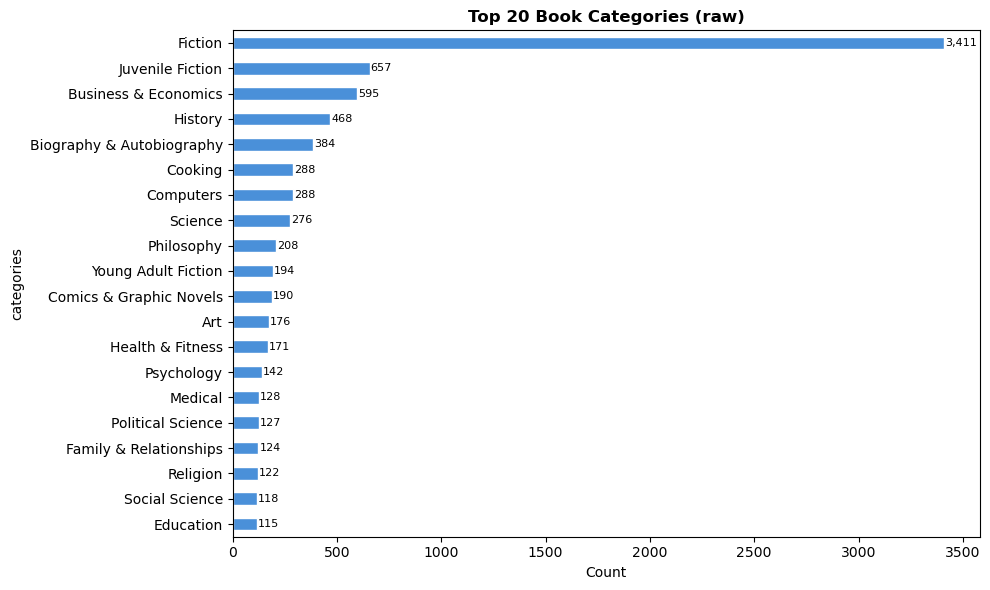

Saved → reports/figures/top_categories_raw.png


In [161]:
if 'categories' in df.columns:
    cats = df['categories'].dropna()
    top_cats = cats.value_counts().head(20)
    print(f'Total unique categories: {cats.nunique():,}')
    print(f'Most common categories:')
    print(top_cats.to_string())

    fig, ax = plt.subplots(figsize=(10, 6))
    top_cats.sort_values().plot(kind='barh', ax=ax, color='#4A90D9', edgecolor='white')
    ax.set_title('Top 20 Book Categories (raw)', fontweight='bold', fontsize=12)
    ax.set_xlabel('Count')
    for bar in ax.patches:
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                f'{int(bar.get_width()):,}', va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig('reports/figures/top_categories_raw.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/figures/top_categories_raw.png')

## 10. Tổng kết — Raw Dataset Health Report

In [162]:
print('=' * 55)
print('   RAW DATASET HEALTH REPORT')
print('=' * 55)
print(f'  Total records         : {len(df):,}')
print(f'  Total columns         : {df.shape[1]}')
print()
print('  KEY COLUMN STATUS:')

key_cols = {
    'description':   'Core NLP input — embedding + retrieval',
    'categories':    'Ground truth proxy for evaluation',
    'thumbnail':     'Book cover image URL',
    'average_rating':'Display + ranking',
    'title':         'Display',
    'authors':       'Display',
}

for col, purpose in key_cols.items():
    if col in df.columns:
        null_pct = df[col].isnull().mean() * 100
        status = '✓ OK' if null_pct < 5 else ('⚠ HIGH MISSING' if null_pct > 30 else '~ MODERATE')
        print(f'  {status:<15} {col:<18} missing={null_pct:.1f}%  | {purpose}')
    else:
        print(f'  ✗ NOT FOUND    {col}')

desc_missing = df['description'].isnull().sum()
est_clean = len(df) - desc_missing
print()
print(f'  Estimated rows after dropping null description: ~{est_clean:,}')
print()
print('  NEXT STEP → Run 02_eda_visualization.ipynb')
print('=' * 55)

   RAW DATASET HEALTH REPORT
  Total records         : 12,688
  Total columns         : 12

  KEY COLUMN STATUS:
  ✓ OK            description        missing=0.0%  | Core NLP input — embedding + retrieval
  ~ MODERATE      categories         missing=10.4%  | Ground truth proxy for evaluation
  ~ MODERATE      thumbnail          missing=6.6%  | Book cover image URL
  ⚠ HIGH MISSING  average_rating     missing=86.3%  | Display + ranking
  ✓ OK            title              missing=0.0%  | Display
  ✓ OK            authors            missing=0.5%  | Display

  Estimated rows after dropping null description: ~12,688

  NEXT STEP → Run 02_eda_visualization.ipynb


## 11. Lưu raw dataset (xác nhận vị trí)

> Notebook này **không thay đổi** dữ liệu gốc.  
> Chỉ xác nhận file tồn tại đúng vị trí để các notebook sau đọc.

In [163]:
assert os.path.exists(RAW_PATH), f'ERROR: Raw file not found at {RAW_PATH}'

file_size = os.path.getsize(RAW_PATH) / 1024
print(f'Raw dataset confirmed at: {RAW_PATH}')
print(f'File size              : {file_size:.1f} KB')
print(f'Rows                   : {len(df):,}')
print(f'Columns                : {list(df.columns)}')
print()
print('Notebook 01 complete. Proceed to 02_eda_visualization.ipynb')

Raw dataset confirmed at: data/raw/books.csv
File size              : 13259.4 KB
Rows                   : 12,688
Columns                : ['isbn13', 'isbn10', 'title', 'subtitle', 'authors', 'categories', 'thumbnail', 'description', 'published_year', 'average_rating', 'num_pages', 'ratings_count']

Notebook 01 complete. Proceed to 02_eda_visualization.ipynb


---
# Phần 2 — Data Cleaning & Preprocessing (Tích hợp từ 03_preprocessing)
**Mục tiêu:** Thực hiện làm sạch dữ liệu thô, loại bỏ các bản ghi lỗi, điền khuyết giá trị trống và lưu lại dữ liệu sạch để sử dụng cho bước trực quan hóa và xây dựng mô hình.

## 3. Cleaning Pipeline

Thực hiện theo bảng trong PRD §5 Step 2.

In [164]:
df_raw = df.copy()
OUT_PATH = 'data/processed/books_clean.csv'
os.makedirs('data/processed', exist_ok=True)
print('Bridge set: df_raw and OUT_PATH initialized.')

Bridge set: df_raw and OUT_PATH initialized.


In [165]:
df = df_raw.copy()
log = []  # track mỗi bước drop bao nhiêu rows

def log_step(name, before, after, action=''):
    removed = before - after
    log.append({'step': name, 'before': before, 'after': after,
                'removed': removed, 'action': action})
    print(f'[{name}] {before:,} → {after:,}  (removed {removed:,})  {action}')

n0 = len(df)
print(f'Start: {n0:,} rows')
print()

Start: 12,688 rows



### 3.1 Drop rows with missing `description`

In [166]:
before = len(df)
df = df.dropna(subset=['description'])

# Lọc mô tả boilerplate public-domain
BOILERPLATE = [
    "this work has been selected by scholars",
    "this is a reproduction of",
    "we appreciate your understanding of the imperfections",
]
_low = df["description"].str.lower()
is_boiler = _low.apply(lambda s: any(p in s for p in BOILERPLATE))
df = df[~is_boiler]

# Also drop description that is too short (< 10 words — likely not useful)
df = df[df['description'].str.split().str.len() >= 10]

log_step('Drop missing/short/boilerplate description', before, len(df),
         'drop: NaN, boilerplate, or < 10 words')

[Drop missing/short/boilerplate description] 12,688 → 12,521  (removed 167)  drop: NaN, boilerplate, or < 10 words


### 3.2 Drop duplicate `isbn13`

In [167]:
before = len(df)

# Drop rows where isbn13 is missing first
df = df.dropna(subset=['isbn13'])

# Keep first occurrence of isbn13
df = df.drop_duplicates(subset=['isbn13'], keep='first')

# Khử trùng lặp edition (tác phẩm) theo title + author
_dlen = df["description"].str.split().str.len()
_key = df["title"].str.lower().str.strip() + "::" + df["authors"].str.lower().str.strip()
df = (
    df.assign(_dlen=_dlen, _key=_key)
      .sort_values("_dlen", ascending=False)
      .drop_duplicates("_key", keep="first")
      .drop(columns=["_dlen", "_key"])
      .sort_index()
)

log_step('Deduplicate isbn13 & edition', before, len(df), 'keep first isbn13 + longest description per title-author')

[Deduplicate isbn13 & edition] 12,521 → 11,692  (removed 829)  keep first isbn13 + longest description per title-author


### 3.3 Outlier filter: `num_pages`

In [168]:
before = len(df)

# Đổi 0 thành NaN (Google Books dùng 0 làm ký hiệu "không rõ số trang")
df['num_pages'] = df['num_pages'].replace(0, pd.NA)

# Keep only rows where num_pages is in [10, 1500] or missing
mask_pages = (
    df['num_pages'].isna() |
    ((df['num_pages'] >= 10) & (df['num_pages'] <= 1500))
)
df = df[mask_pages]

log_step('Filter num_pages outliers (0->NaN)', before, len(df), 'keep 10–1500 or NaN')

[Filter num_pages outliers (0->NaN)] 11,692 → 11,606  (removed 86)  keep 10–1500 or NaN


### 3.4 Outlier filter: `published_year`

In [169]:
before = len(df)

mask_year = (
    df['published_year'].isna() |
    ((df['published_year'] >= 1800) & (df['published_year'] <= 2026))
)
df = df[mask_year]

log_step('Filter published_year outliers', before, len(df), 'keep 1800–2026 or NaN')

[Filter published_year outliers] 11,606 → 11,606  (removed 0)  keep 1800–2026 or NaN


### 3.5 Fill missing values

In [170]:
PLACEHOLDER_THUMB = 'https://via.placeholder.com/128x192.png?text=No+Cover'

# thumbnail → placeholder URL
df['thumbnail'] = df['thumbnail'].fillna(PLACEHOLDER_THUMB)

# categories → 'Unknown'
df['categories'] = df['categories'].fillna('Unknown')

# authors → 'Unknown'
df['authors'] = df['authors'].fillna('Unknown')

# num_pages → median
pages_median = df['num_pages'].median()
df['num_pages'] = df['num_pages'].fillna(pages_median)

# published_year → median cast to int
year_median = int(df['published_year'].median())
df['published_year'] = df['published_year'].fillna(year_median).astype(int)

print('Fill summary:')
print(f'  thumbnail fill value   : placeholder URL')
print(f'  num_pages median       : {pages_median:.0f}')
print(f'  published_year median  : {year_median}')
print(f'  categories fill value  : "Unknown"')
print()
print(f'Remaining missing after fills:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Fill summary:
  thumbnail fill value   : placeholder URL
  num_pages median       : 298
  published_year median  : 2013
  categories fill value  : "Unknown"

Remaining missing after fills:
isbn10              539
subtitle           6476
average_rating    10027
ratings_count     10027
dtype: int64


## 4. Feature Engineering

In [171]:
# description_length: word count
df['description_length'] = df['description'].str.split().str.len()

# book_age: years since publication (CURRENT_YEAR = 2026)
df['book_age'] = 2026 - df['published_year']

# tag_clean: lowercased, stripped categories
df['tag_clean'] = df['categories'].str.lower().str.strip()

print('New features added:')
print(df[['description_length', 'book_age', 'tag_clean']].describe(include='all'))

New features added:
        description_length      book_age tag_clean
count         11606.000000  11606.000000     11606
unique                 NaN           NaN       842
top                    NaN           NaN   fiction
freq                   NaN           NaN      3039
mean            138.393073     15.268482       NaN
std             105.110785     11.398131       NaN
min              20.000000      0.000000       NaN
25%              48.000000      7.000000       NaN
50%             119.000000     13.000000       NaN
75%             196.000000     21.000000       NaN
max            1048.000000    213.000000       NaN


## 5. Clean Description Text

Chỉ normalize nhẹ — **không** stemming/lemmatization vì:
- TF-IDF hoạt động tốt trên raw text với `TfidfVectorizer` built-in tokenizer
- BGE embedding model xử lý raw text tốt hơn text đã bị biến đổi

In [172]:
import re

def clean_text(text: str) -> str:
    """Light normalization: strip HTML tags, collapse whitespace, fix encoding."""
    if not isinstance(text, str):
        return ''
    # Remove HTML tags (e.g. <br>, <b>)
    text = re.sub(r'<[^>]+>', ' ', text)
    # Remove URLs
    text = re.sub(r'https?://\S+', '', text)
    # Collapse multiple whitespace / newlines
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['description'] = df['description'].apply(clean_text)

# Re-compute description_length after cleaning
df['description_length'] = df['description'].str.split().str.len()

# Drop rows where description became empty after cleaning
before = len(df)
df = df[df['description_length'] >= 10]
log_step('Drop empty description after clean_text', before, len(df))

print(f'\nSample cleaned description:')
print(df['description'].iloc[0][:300])

[Drop empty description after clean_text] 11,606 → 11,606  (removed 0)  

Sample cleaned description:
This is the ultimate reference book on the World Cup, with match-by-match articles featuring the biggest names in world football, plus results from every game played. All the statistics are here in one volume, enough to satisfy the most avid of World Cup fans, including team line-ups, goalscorers, s


## 6. Select & Order Final Columns

In [173]:
# Required columns theo PRD §5 Step 5
FINAL_COLS = [
    'isbn13',
    'title',
    'authors',
    'description',
    'categories',
    'tag_clean',
    'thumbnail',
    'published_year',
    'num_pages',
    'description_length',
    'book_age',
]

# Only keep columns that actually exist in df
final_cols = [c for c in FINAL_COLS if c in df.columns]
missing_cols = [c for c in FINAL_COLS if c not in df.columns]
if missing_cols:
    print(f'Warning — columns not found in raw data: {missing_cols}')
    print('  → skipping those columns (check raw CSV header names)')

df_final = df[final_cols].reset_index(drop=True)
print(f'Final columns  : {df_final.columns.tolist()}')
print(f'Final shape    : {df_final.shape}')

Final columns  : ['isbn13', 'title', 'authors', 'description', 'categories', 'tag_clean', 'thumbnail', 'published_year', 'num_pages', 'description_length', 'book_age']
Final shape    : (11606, 11)


## 7. Final Validation

In [174]:
print('=== Final Validation ===')

# 1. No missing in mandatory columns
mandatory = ['isbn13', 'title', 'description', 'categories', 'thumbnail']
mandatory_present = [c for c in mandatory if c in df_final.columns]
missing_mandatory = df_final[mandatory_present].isnull().sum()
print('Missing in mandatory columns:')
print(missing_mandatory)
assert missing_mandatory.sum() == 0, 'ERROR: mandatory columns still have nulls!'

# 2. isbn13 unique
assert df_final['isbn13'].nunique() == len(df_final), 'ERROR: duplicate isbn13!'
print('✓ isbn13 all unique')

# 3. description_length >= 10
assert (df_final['description_length'] >= 10).all(), 'ERROR: short descriptions found!'
print('✓ All descriptions >= 10 words')

print()
print('=== Pipeline Summary ===')
pd.DataFrame(log)

=== Final Validation ===
Missing in mandatory columns:
isbn13         0
title          0
description    0
categories     0
thumbnail      0
dtype: int64
✓ isbn13 all unique
✓ All descriptions >= 10 words

=== Pipeline Summary ===


,step,before,after,removed,action
0,Drop missing/short/boilerplate description,12688,12521,167,"drop: NaN, boilerplate, or < 10 words"
1,Deduplicate isbn13 & edition,12521,11692,829,keep first isbn13 + longest description per ti...
2,Filter num_pages outliers (0->NaN),11692,11606,86,keep 10–1500 or NaN
3,Filter published_year outliers,11606,11606,0,keep 1800–2026 or NaN
4,Drop empty description after clean_text,11606,11606,0,


## 8. Save Clean Dataset

In [175]:
df_final.to_csv(OUT_PATH, index=False)
print(f'Saved → {OUT_PATH}')
print(f'Rows   : {len(df_final):,}')
print(f'Columns: {len(df_final.columns)}')
print()
df_final.head(3)

Saved → data/processed/books_clean.csv
Rows   : 11,606
Columns: 11



,isbn13,title,authors,description,categories,tag_clean,thumbnail,published_year,num_pages,description_length,book_age
0,9780002188319,The Complete Book of the World Cup,Cris Freddi,This is the ultimate reference book on the Wor...,Soccer,soccer,https://books.google.com/books/content?id=HGbQ...,1998,352.0,148,28
1,9780002240802,The Last Thing He Wanted,Joan Didion,"Journalist Elena McMahon watches her evasive, ...",Adventure stories,adventure stories,https://via.placeholder.com/128x192.png?text=N...,1997,227.0,46,29
2,9780002246484,Royal Assassin,Robin Hobb,Barely escaping with his life after his first ...,Assassins,assassins,https://books.google.com/books/content?id=B_Dt...,1996,579.0,57,30


## 9. Quick Stats on Clean Dataset

In [176]:
print('=== Numeric Summary ===')
display_cols = ['description_length', 'book_age', 'num_pages']
display_cols_present = [c for c in display_cols if c in df_final.columns]
df_final[display_cols_present].describe().round(2)

=== Numeric Summary ===


,description_length,book_age
count,11606.00,11606.00
mean,138.39,15.27
std,105.11,11.40
min,20.00,0.00
25%,48.00,7.00
50%,119.00,13.00
75%,196.00,21.00
max,1048.00,213.00


In [177]:
print('=== Category Distribution (Top 10) ===')
print(df_final['categories'].value_counts().head(10).to_string())

=== Category Distribution (Top 10) ===
categories
Fiction                      3018
Unknown                      1121
Juvenile Fiction              600
Business & Economics          584
History                       422
Biography & Autobiography     364
Computers                     283
Cooking                       278
Science                       257
Philosophy                    198
